In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
os.chdir('C:/Users/amydu/OneDrive/Documents/UoB_Interview_Task')

In [3]:
patients = pd.read_csv('dummy_data/patients_table.csv', index_col=0)
admissions = pd.read_csv('dummy_data/patient_admissions.csv', index_col=0)
diagnosis = pd.read_csv('dummy_data/disease_diagnosis_code.csv', index_col=0)

In [4]:
patients.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
24,10000690,F,86,2150,2008 - 2010,2152-01-30
69,10001919,M,59,2124,2017 - 2019,2124-12-20
102,10002667,F,58,2187,2020 - 2022,NaN
274,10007117,F,22,2189,2020 - 2022,NaN
277,10007174,M,70,2162,2011 - 2013,NaN


In [5]:
print(len(patients))
print(len(patients['subject_id'].unique()))
#5000 patients total 

5000
5000


In [6]:
admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
16,10000690,23280645,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,EW EMER.,P941QM,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0
17,10000690,25860671,2150-11-02 18:02:00,2150-11-12 13:45:00,NaN,EW EMER.,P26QQ4,EMERGENCY ROOM,REHAB,Medicare,English,WIDOWED,WHITE,2150-11-02 11:41:00,2150-11-02 19:37:00,0
18,10000690,26146595,2152-01-28 23:40:00,2152-01-30 15:56:00,NaN,EW EMER.,P61PLH,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,2152-01-28 15:41:00,2152-01-29 01:22:00,0
19,10000690,26504700,2150-07-03 02:46:00,2150-07-07 15:42:00,NaN,EW EMER.,P46JQK,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,2150-07-02 22:59:00,2150-07-03 03:55:00,0
97,10001919,29897682,2124-04-20 00:00:00,2124-04-21 13:47:00,NaN,SURGICAL SAME DAY ADMISSION,P64FA3,PHYSICIAN REFERRAL,HOME,Private,English,MARRIED,OTHER,NaN,NaN,0


In [8]:
print(len(admissions))
print(admissions['hospital_expire_flag'].value_counts())
print(admissions['marital_status'].value_counts())

11828
hospital_expire_flag
0    11554
1      274
Name: count, dtype: int64
marital_status
MARRIED     4982
SINGLE      4452
WIDOWED     1166
DIVORCED     918
Name: count, dtype: int64


C:\Users\amydu\AppData\Local\Temp\ipykernel_22108\1104939679.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing, y=missing.index, palette="viridis")


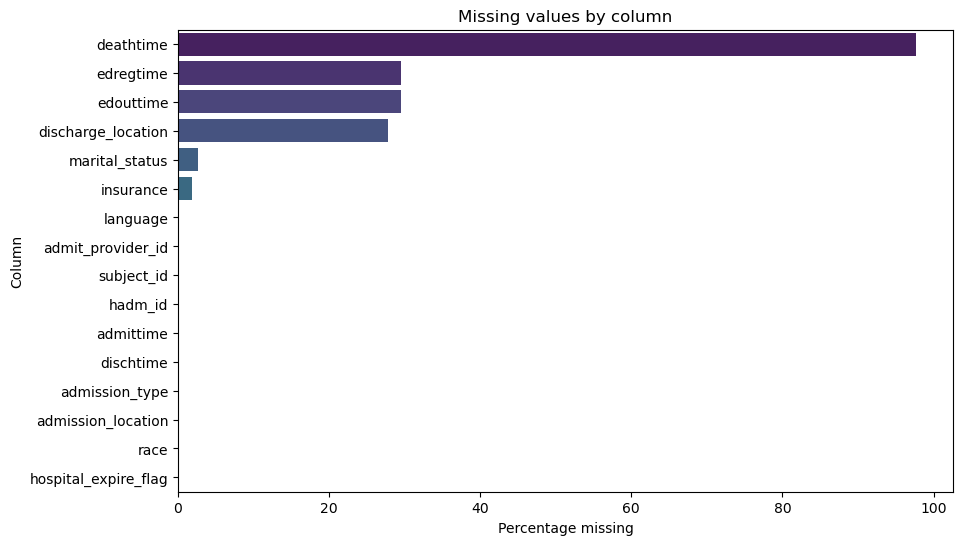

In [9]:
missing = admissions.isnull().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10,6))
sns.barplot(x=missing, y=missing.index, palette="viridis")
plt.xlabel("Percentage missing")
plt.ylabel("Column")
plt.title("Missing values by column")
plt.show()

In [10]:
diagnosis.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version
100,10000690,23280645,1,4280,9
101,10000690,23280645,2,486,9
102,10000690,23280645,3,4271,9
103,10000690,23280645,4,2764,9
104,10000690,23280645,5,42833,9


In [11]:
print(len(diagnosis['hadm_id'].unique()))
print(len(diagnosis))
print(diagnosis['icd_version'].value_counts())

11819
137636
icd_version
10    75206
9     62430
Name: count, dtype: int64


In [12]:
from icd_mapping import _read_icd9_to10_gem, convert_to_icd10

_read_icd9_to10_gem("dummy_data/2018_I9gem.txt")

#C:\Users\amydu\OneDrive\Documents\UoB_Interview_Task\dummy_data\2018_I9gem.txt

out = convert_to_icd10(
    diagnosis,
    code_col="icd_code",
    icd_version_col="icd_version",
    icd9_to10_gem_path="dummy_data/2018_I9gem.txt")

out.head()
out.to_csv('dummy_data/diagnosis_icd10.csv', index=False)

In [13]:
out["target_system"].value_counts()

target_system
ICD10    175321
Name: count, dtype: int64

In [14]:
out.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version,target_system,target_code
0,10000690,23280645,1,4280,9,ICD10,I50814
1,10000690,23280645,1,4280,9,ICD10,I509
2,10000690,23280645,2,486,9,ICD10,J189
3,10000690,23280645,3,4271,9,ICD10,I472
4,10000690,23280645,4,2764,9,ICD10,E874


In [15]:
out_clean = out.drop(columns=['icd_version', 'icd_code', 'target_system','subject_id'], axis=1)

In [16]:
out_clean.head()

,hadm_id,seq_num,target_code
0,23280645,1,I50814
1,23280645,1,I509
2,23280645,2,J189
3,23280645,3,I472
4,23280645,4,E874


In [17]:
out_clean.to_csv('dummy_data/diagnosis_icd10.csv', index=False)

In [18]:
#read in dataframe containing CCSR mapping for ICD10 codes 
CSS = pd.read_csv('dummy_data/DXCCSR_v2025-1.csv')

#Create target_code column to match with out_clean dataframe
CSS['target_code'] = CSS["'ICD-10-CM CODE'"].str.upper().str.replace('.', '', regex=False).str.strip('"').str.strip("'").str.strip(" ")

# Map using default inpatient category
map_ccsr = CSS[['target_code', "'Default CCSR CATEGORY IP'"]]

# Rename columns for merging
map_ccsr = map_ccsr.rename(columns={
    "'Default CCSR CATEGORY IP'": 'ccs_cat'
})

# Merge with out_clean dataframe to get a CCSR category for each diagnosis code
df_ccsr = out_clean.merge(map_ccsr, on='target_code', how='left')

C:\Users\amydu\AppData\Local\Temp\ipykernel_22108\3212891055.py:2: DtypeWarning: Columns (15,17) have mixed types. Specify dtype option on import or set low_memory=False.
  CSS = pd.read_csv('dummy_data/DXCCSR_v2025-1.csv')


In [19]:
# create a dataframe of one row per admission
df_short = df_ccsr.copy()

# drop disease codes - we only use CCS codes from now on
df_short.drop(columns=['target_code'], inplace=True)

In [20]:
# 0) Clean CCS codes (strip quotes, upper-case)
df_short['ccs_cat'] = (df_short['ccs_cat']
                  .astype(str)
                  .str.strip('"').str.strip("'").str.upper())


# 2) Sort to respect the within-admission order
# If seq_num ties or NaNs exist, use ccsr_cat as a stable tiebreaker
df_short = df_short.sort_values(['hadm_id', 'seq_num', 'ccs_cat'], na_position='last')

# 3) Option A: Ordered sequence per admission (keep duplicates if you want exact order)
adm_seq = (
    df_short.groupby('hadm_id', sort=False)['ccs_cat'] # groups by admission and selects ccs column
            .agg(lambda s: [str(v) for v in s.dropna().tolist()]) #applies aggregation function to each group
            #aggregates each group into a list of strings, dropping NaN values
            .reset_index(name='ccs_seq') # resets index so hadm_id becomes a column again
            #renames new column ccs_seq
)

# 4) Add sequence length as a feature
# this tells us the number of diagnosis codes recorded during the admission
adm_seq['ccs_seq_len'] = adm_seq['ccs_seq'].map(len)


In [21]:
adm_seq.head()

,hadm_id,ccs_seq,ccs_seq_len
0,20000057,"[MUS007, MUS007, MUS010, INJ035, INJ035, INJ03...",29
1,20000159,"[BLD009, BLD009, BLD009, BLD009, CIR038, CIR03...",65
2,20002318,"[XXX000, DIG017, BLD007, SYM014, SYM014]",5
3,20002699,"[DIG019, BLD001, MBD017, SYM006, RSP008, CIR00...",7
4,20002706,"[NVS020, SYM007, SYM007, SYM007, DIG022, DIG02...",13


In [22]:
# save cleaned data as csv
adm_seq.to_csv('dummy_data/diagnosis_css_sequences.csv', index=False)

In [23]:
# merge admissions and diagnosis dataframes by hadm_id and subject_id     
merged = pd.merge(admissions, adm_seq, on='hadm_id', how='left')   
len(merged)       

11828

In [24]:
merged.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,ccs_seq,ccs_seq_len
0,10000690,23280645,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,EW EMER.,P941QM,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,"[CIR019, CIR019, RSP002, CIR017, END011, CIR01...",18.0
1,10000690,25860671,2150-11-02 18:02:00,2150-11-12 13:45:00,NaN,EW EMER.,P26QQ4,EMERGENCY ROOM,REHAB,Medicare,English,WIDOWED,WHITE,2150-11-02 11:41:00,2150-11-02 19:37:00,0,"[RSP010, CIR019, RSP012, RSP012, GEN002, DIG02...",29.0
2,10000690,26146595,2152-01-28 23:40:00,2152-01-30 15:56:00,NaN,EW EMER.,P61PLH,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,2152-01-28 15:41:00,2152-01-29 01:22:00,0,"[DIG012, DIG012, DIG012, GEN002, CIR019, NVS01...",23.0
3,10000690,26504700,2150-07-03 02:46:00,2150-07-07 15:42:00,NaN,EW EMER.,P46JQK,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,2150-07-02 22:59:00,2150-07-03 03:55:00,0,"[CIR019, CIR019, CIR019, CIR003, CIR003, SYM01...",13.0
4,10001919,29897682,2124-04-20 00:00:00,2124-04-21 13:47:00,NaN,SURGICAL SAME DAY ADMISSION,P64FA3,PHYSICIAN REFERRAL,HOME,Private,English,MARRIED,OTHER,NaN,NaN,0,"[NEO013, NEO070, CIR033, DIG024, XXX000, XXX00...",11.0


In [25]:
# merge with patients dataframe 
# patients will be repeated across admissions
merged_again = pd.merge(merged, patients, on='subject_id', how='left')  

In [26]:
len(merged_again)
# dataframe contains one row per admission
# there are 11828 admissions in total 

11828

In [27]:
merged_again.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,edregtime,edouttime,hospital_expire_flag,ccs_seq,ccs_seq_len,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000690,23280645,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,EW EMER.,P941QM,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,...,2150-09-16 16:00:00,2150-09-16 21:03:00,0,"[CIR019, CIR019, RSP002, CIR017, END011, CIR01...",18.0,F,86,2150,2008 - 2010,2152-01-30
1,10000690,25860671,2150-11-02 18:02:00,2150-11-12 13:45:00,NaN,EW EMER.,P26QQ4,EMERGENCY ROOM,REHAB,Medicare,...,2150-11-02 11:41:00,2150-11-02 19:37:00,0,"[RSP010, CIR019, RSP012, RSP012, GEN002, DIG02...",29.0,F,86,2150,2008 - 2010,2152-01-30
2,10000690,26146595,2152-01-28 23:40:00,2152-01-30 15:56:00,NaN,EW EMER.,P61PLH,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,...,2152-01-28 15:41:00,2152-01-29 01:22:00,0,"[DIG012, DIG012, DIG012, GEN002, CIR019, NVS01...",23.0,F,86,2150,2008 - 2010,2152-01-30
3,10000690,26504700,2150-07-03 02:46:00,2150-07-07 15:42:00,NaN,EW EMER.,P46JQK,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,...,2150-07-02 22:59:00,2150-07-03 03:55:00,0,"[CIR019, CIR019, CIR019, CIR003, CIR003, SYM01...",13.0,F,86,2150,2008 - 2010,2152-01-30
4,10001919,29897682,2124-04-20 00:00:00,2124-04-21 13:47:00,NaN,SURGICAL SAME DAY ADMISSION,P64FA3,PHYSICIAN REFERRAL,HOME,Private,...,NaN,NaN,0,"[NEO013, NEO070, CIR033, DIG024, XXX000, XXX00...",11.0,M,59,2124,2017 - 2019,2124-12-20


In [28]:
merged_again.columns

Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime',
       'admission_type', 'admit_provider_id', 'admission_location',
       'discharge_location', 'insurance', 'language', 'marital_status', 'race',
       'edregtime', 'edouttime', 'hospital_expire_flag', 'ccs_seq',
       'ccs_seq_len', 'gender', 'anchor_age', 'anchor_year',
       'anchor_year_group', 'dod'],
      dtype='object')

C:\Users\amydu\AppData\Local\Temp\ipykernel_22108\4191413050.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing, y=missing.index, palette="viridis")


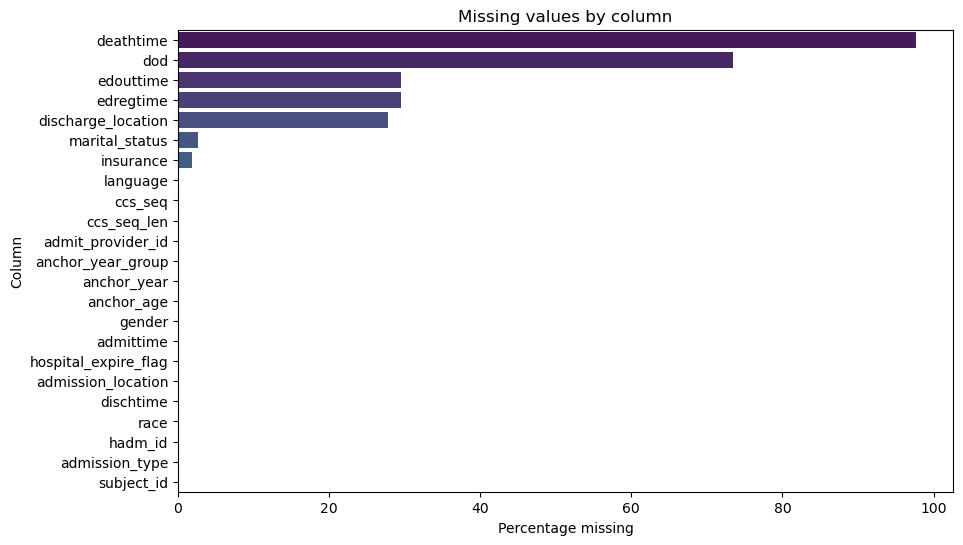

In [29]:
#visualise missing values
missing = merged_again.isnull().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10,6))
sns.barplot(x=missing, y=missing.index, palette="viridis")
plt.xlabel("Percentage missing")
plt.ylabel("Column")
plt.title("Missing values by column")
plt.show()

In [30]:
df = merged_again.copy()

# convert admittime and dischtime to datetime format
df['admittime'] = pd.to_datetime(df['admittime'], errors='coerce')
df['dischtime']   = pd.to_datetime(df['dischtime'], errors='coerce')

# Add 1 day if discharge is earlier than admission
# this accounts for admissions that span midnight
mask = df['dischtime'] < df['admittime']
df.loc[mask, 'dischtime'] = df.loc[mask, 'dischtime'] + pd.Timedelta(days=1)

# Calculate duration
df['admission_duration'] = df['dischtime'] - df['admittime']

# convert duration to number of days (as a float)
df['admission_duration'] = df['admission_duration'].dt.total_seconds() / (24 * 60 * 60)

In [31]:
print(df['admission_duration'].value_counts())

admission_duration
0.706250     10
0.984722      9
1.894444      8
1.791667      8
1.022917      8
             ..
5.839583      1
20.935417     1
8.711111      1
1.571528      1
8.181250      1
Name: count, Length: 7615, dtype: int64


In [32]:
# check for negative durations - this should be zero now after the fix above
bad_rows = df[df['admission_duration'] < 0]
print(bad_rows[['admission_duration', 'admittime', 'dischtime']])

Empty DataFrame
Columns: [admission_duration, admittime, dischtime]
Index: []


In [33]:
# convert edregtime and edouttime to datetime format
df['edregtime'] = pd.to_datetime(df['edregtime'], errors='coerce')
df['edouttime']   = pd.to_datetime(df['edouttime'], errors='coerce')

# Add 1 day if discharge is earlier than admission
mask = df['edouttime'] < df['edregtime']
df.loc[mask, 'edouttime'] = df.loc[mask, 'edouttime'] + pd.Timedelta(days=1)

# Calculate duration
df['ed_duration'] = df['edouttime'] - df['edregtime']

# convert duration to number of days (as a float)
df['ed_duration'] = df['ed_duration'].dt.total_seconds() / (24 * 60 * 60)

In [34]:
print(df['ed_duration'].value_counts())

ed_duration
0.264583    28
0.266667    26
0.275000    24
0.236806    23
0.195833    23
            ..
1.374306     1
1.185417     1
1.963194     1
0.854167     1
3.506944     1
Name: count, Length: 1767, dtype: int64


In [ ]:
# Extract the year of admission, deidentified by the anchor year
df['admission_year'] = df['admittime'].dt.year

# Calculate age at admission using the difference between admission year and anchor year
# Add this difference to the anchor age to get age at admission
df['age_at_admission'] = df['anchor_age'] + (df['admission_year'] - df['anchor_year'])

# Clip ages at 0 (in case of weird synthetic offsets)
df['age_at_admission'] = df['age_at_admission'].clip(lower=0)

# Drop helper column
df = df.drop(columns=['admission_year'])

In [ ]:
# admission features from datetime library 
df['admit_hour']     = df['admittime'].dt.hour # 0-23
df['admit_weekday']  = df['admittime'].dt.weekday   # 0=Mon, 6=Sun
df['admit_month']    = df['admittime'].dt.month # 1-12
df['is_weekend']     = df['admit_weekday'].isin([5,6]).astype(int) # weekend if Sat or Sun
df['is_night_admit'] = df['admit_hour'].isin(list(range(0,8)) + list(range(20,24))).astype(int) # night if 12am-8am or 8pm-12am

In [ ]:
# Cyclic timing encodings
# transform the time variables using sin/cos transformations to capture their cyclical nature
df['hour_sin'] = np.sin(2*np.pi*df['admit_hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['admit_hour']/24)
df['dow_sin']  = np.sin(2*np.pi*df['admit_weekday']/7)
df['dow_cos']  = np.cos(2*np.pi*df['admit_weekday']/7)
df['mon_sin']  = np.sin(2*np.pi*(df['admit_month']-1)/12)
df['mon_cos']  = np.cos(2*np.pi*(df['admit_month']-1)/12)

In [ ]:
# sort by patient and admission time
df = df.sort_values(['subject_id', 'admittime'])

# admission index per patient (0,1,2,...)
df['admission_index'] = df.groupby('subject_id').cumcount()

# previous discharge time per patient (shifted)
df['prev_discharge'] = df.groupby('subject_id')['dischtime'].shift(1)

# days since previous admission (use prev discharge, not current discharge)
delta = (df['admittime'] - df['prev_discharge']).dt.total_seconds() / 86400

# If prev_discharge is NaT (first admission) or negative due to data quirks -> set to 0 or NaN by choice
df['days_since_prev_admission'] = delta.where(delta.notna(), np.nan)
df.loc[df['days_since_prev_admission'] < 0, 'days_since_prev_admission'] = 0.0

# days since first admission (relative to the patient's first admittime)
first_admit = df.groupby('subject_id')['admittime'].transform('min')
df['days_since_first_admission'] = (df['admittime'] - first_admit).dt.total_seconds() / 86400

# prior admissions count (history-only)
df['num_prior_admissions'] = df['admission_index']

# Clean up helper columns if you won’t use them as inputs
# (Keep admittime/dischtime for now if you’ll engineer more features; drop before modeling)
# df = df.drop(columns=['admission_year', 'prev_discharge'])

In [142]:
df.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,hour_cos,dow_sin,dow_cos,mon_sin,mon_cos,admission_index,prev_discharge,days_since_prev_admission,days_since_first_admission,num_prior_admissions
3,10000690,26504700,2150-07-03 02:46:00,2150-07-07 15:42:00,NaN,EW EMER.,P46JQK,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,...,8.660254e-01,-0.433884,-0.900969,1.224647e-16,-1.000000e+00,0,NaT,NaN,0.000000,0
0,10000690,23280645,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,EW EMER.,P941QM,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,...,2.588190e-01,0.974928,-0.222521,-8.660254e-01,-5.000000e-01,1,2150-07-07 15:42:00,71.170833,75.709722,1
1,10000690,25860671,2150-11-02 18:02:00,2150-11-12 13:45:00,NaN,EW EMER.,P26QQ4,EMERGENCY ROOM,REHAB,Medicare,...,-1.836970e-16,0.000000,1.000000,-8.660254e-01,5.000000e-01,2,2150-09-24 13:50:00,39.175000,122.636111,2
2,10000690,26146595,2152-01-28 23:40:00,2152-01-30 15:56:00,NaN,EW EMER.,P61PLH,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,...,9.659258e-01,-0.433884,-0.900969,0.000000e+00,1.000000e+00,3,2150-11-12 13:45:00,442.413194,574.870833,3
4,10001919,29897682,2124-04-20 00:00:00,2124-04-21 13:47:00,NaN,SURGICAL SAME DAY ADMISSION,P64FA3,PHYSICIAN REFERRAL,HOME,Private,...,1.000000e+00,0.433884,-0.900969,1.000000e+00,6.123234e-17,0,NaT,NaN,0.000000,0


In [143]:
df.columns

Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime',
       'admission_type', 'admit_provider_id', 'admission_location',
       'discharge_location', 'insurance', 'language', 'marital_status', 'race',
       'edregtime', 'edouttime', 'hospital_expire_flag', 'ccs_seq',
       'ccs_seq_len', 'gender', 'anchor_age', 'anchor_year',
       'anchor_year_group', 'dod', 'admission_duration', 'ed_duration',
       'age_at_admission', 'admit_hour', 'admit_weekday', 'admit_month',
       'is_weekend', 'is_night_admit', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos', 'mon_sin', 'mon_cos', 'admission_index', 'prev_discharge',
       'days_since_prev_admission', 'days_since_first_admission',
       'num_prior_admissions'],
      dtype='object')

In [ ]:
# drop columns not needed for modeling
df_model = df.drop(columns=["admittime", "dischtime", "edregtime", "edouttime", "deathtime", "dod", "admit_provider_id", "anchor_age", "anchor_year", "prev_discharge"], axis=1)

C:\Users\amydu\AppData\Local\Temp\ipykernel_30660\1178332971.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing, y=missing.index, palette="viridis")


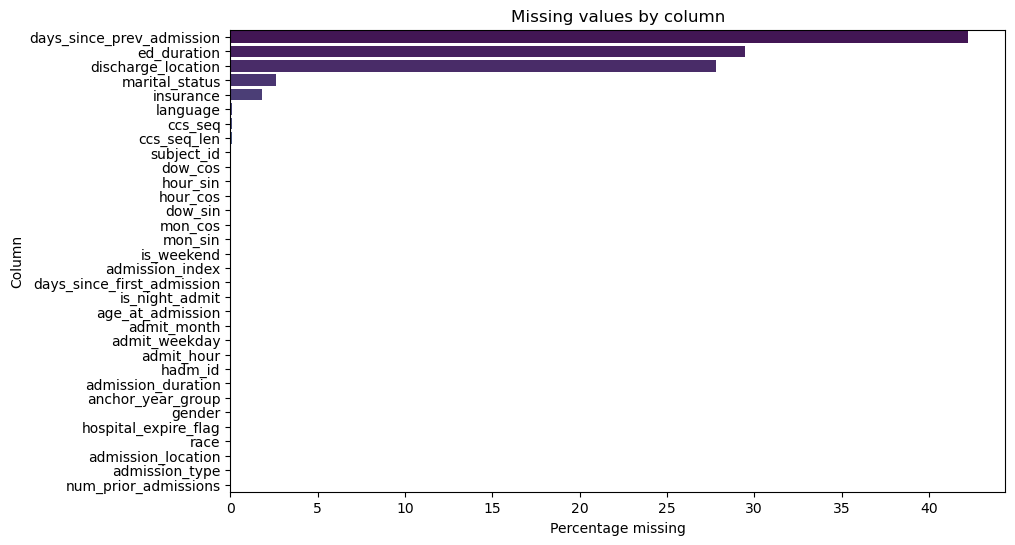

In [ ]:
# visualise missing values after feature engineering
missing = df_model.isnull().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10,6))
sns.barplot(x=missing, y=missing.index, palette="viridis")
plt.xlabel("Percentage missing")
plt.ylabel("Column")
plt.title("Missing values by column")
plt.show()

In [ ]:
# fill missing values

# create binary indicator for prior admission
df_model['has_prior_admission'] = df_model['days_since_prev_admission'].notna().astype(int)
# fill missing days_since_prev_admission with 0 (for first admissions)
df_model['days_since_prev_admission'] = df_model['days_since_prev_admission'].fillna(0)

#for tree based models, no need to fill missing values for ed_duration
#however, need to fill for deep learning models
# df_model['ed_duration'] = df_model['ed_duration'].fillna(0)

In [148]:
df_model["has_prior_admission"].value_counts()

has_prior_admission
1    6828
0    5000
Name: count, dtype: int64

In [149]:
##fill missing values for categorical features##
# Identify categorical columns
#cat_cols = df_model.select_dtypes(include=["object", "category"]).columns.tolist()

# Fill NaNs with "MISSING" for all categorical features except ed_duration
#df_model[cat_cols] = df_model[cat_cols].fillna("MISSING")

C:\Users\amydu\AppData\Local\Temp\ipykernel_30660\1178332971.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing, y=missing.index, palette="viridis")


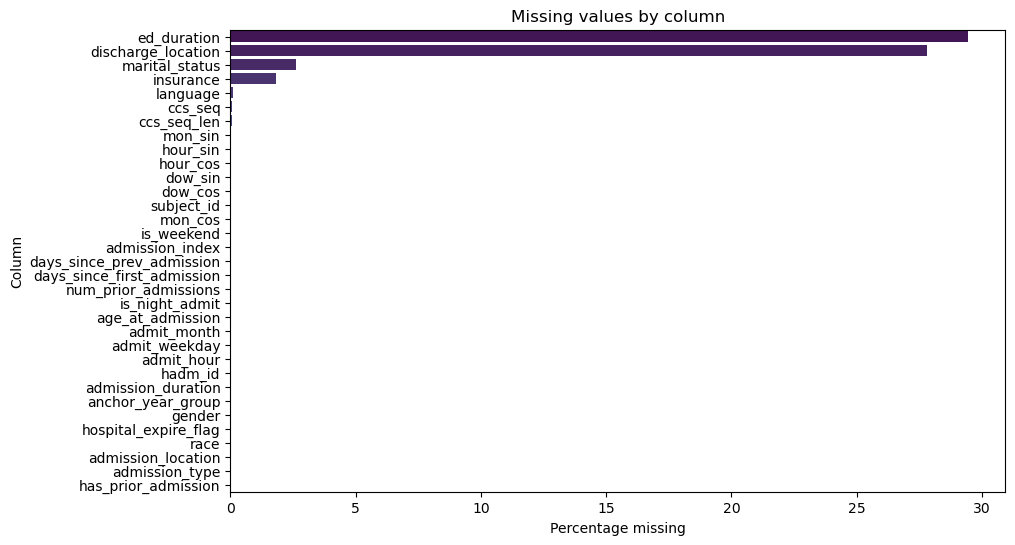

In [ ]:
# leave missing values as NaN for one-hot encoding later
# this is because xgboost/rf can handle missing values
missing = df_model.isnull().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10,6))
sns.barplot(x=missing, y=missing.index, palette="viridis")
plt.xlabel("Percentage missing")
plt.ylabel("Column")
plt.title("Missing values by column")
plt.show()

In [ ]:
# drop columns to avoid data leakage
df_model = df_model.drop(columns=['discharge_location', 'admit_hour', 'admit_weekday', 'admit_month'], axis=1) 

# save cleaned data
df_model.to_csv('dummy_data/cleaned_data.csv', index=False)